In [38]:
import pandas as pd
import bt as bt
import yfinance as yf
import matplotlib
import datetime as dt
import numpy as np
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
from scipy.optimize import minimize
%matplotlib inline

In [39]:
inicio = dt.date(2010, 1, 1)
final = dt.date(2024, 10, 31)

In [ ]:
##carteira_vo = ["CRAA11", "MCHY11", "VGIR11", "JURO11", "RZAK11", "KNCR11", "HGCR11"]
##carteira_mae = ["BRAP4", "CSMG3", "ITUB4"]

##carteira_vo_v2 = ["CRAA11", "MCHY11", "VGIR11", "JURO11", "RZAK11", "KNCR11", "HGCR11"]
##carteira_mae_v2 = ["BRAP4", "CSMG3", "ITUB4", "PRIO3", "SANB11"]

ativos_novos = np.setdiff1d(carteira_11511243_v2, carteira_11511243) ##verificar a diferença entre as carteiras 1 e 2
ativos_novos

array(['JURO11', 'KNCR11'], dtype='<U6')

In [41]:
carteira = carteira_11511243_v2
carteira = [acao + ".SA" for acao in carteira]
precos = yf.download(carteira, inicio, final)['Adj Close']
precos.dropna(inplace=True)
precos

[*********************100%***********************]  8 of 8 completed


Ticker,FGAA11.SA,JURO11.SA,KNCR11.SA,KNHF11.SA,MCRE11.SA,RBHG11.SA,RBRX11.SA,SPXS11.SA
Date,,,,,,,,
2023-08-22 00:00:00+00:00,8.356316,91.579414,85.316086,91.161301,5.888801,77.089851,7.869118,8.411007
2023-08-23 00:00:00+00:00,8.373029,91.829247,85.419624,90.397720,5.910931,77.364914,7.848640,8.290545
2023-08-24 00:00:00+00:00,8.381384,91.389870,85.462769,90.309975,5.936836,77.296150,7.788918,8.294815
2023-08-25 00:00:00+00:00,8.373029,91.605255,85.600815,90.266083,5.974076,77.364914,7.765882,8.457994
2023-08-28 00:00:00+00:00,8.356316,91.553558,85.574936,90.222206,5.985409,76.849144,7.849493,8.457141
...,...,...,...,...,...,...,...,...
2024-10-24 00:00:00+00:00,7.818213,102.298729,102.757317,86.766632,8.417102,79.668884,8.070584,8.871753
2024-10-25 00:00:00+00:00,7.897185,103.685295,103.054390,87.113106,8.476377,80.401154,8.090390,9.039891
2024-10-28 00:00:00+00:00,7.936671,103.606064,102.598885,88.865265,8.594928,80.312096,8.209220,9.059671


In [42]:
retornos = precos.pct_change().apply(lambda x: np.log(1+x)).dropna()
media_retornos = retornos.mean()
matriz_cov = retornos.cov() 
media_retornos

Ticker
FGAA11.SA   -0.000139
JURO11.SA    0.000402
KNCR11.SA    0.000636
KNHF11.SA   -0.000122
MCRE11.SA    0.001183
RBHG11.SA    0.000154
RBRX11.SA    0.000217
SPXS11.SA    0.000296
dtype: float64

In [43]:
numero_carteiras = 100000
tabela_retornos_esperados = np.zeros(numero_carteiras)
tabela_volatilidades_esperadas = np.zeros(numero_carteiras)
tabela_sharpe = np.zeros(numero_carteiras)
tabela_pesos = np.zeros((numero_carteiras, len(carteira)))

for k in range(numero_carteiras):
    
    pesos = np.random.random(len(carteira))
    pesos = pesos/np.sum(pesos)
    tabela_pesos[k, :] = pesos
    
    tabela_retornos_esperados[k] = np.sum(media_retornos * pesos * 252)
    tabela_volatilidades_esperadas[k] = np.sqrt(np.dot(pesos.T, np.dot(matriz_cov*252, pesos)))
    
    tabela_sharpe[k] = tabela_retornos_esperados[k]/tabela_volatilidades_esperadas[k]

In [44]:
indice_do_sharpe_maximo = tabela_sharpe.argmax()
tabela_pesos[indice_do_sharpe_maximo]

array([0.00243043, 0.19353191, 0.43185595, 0.00240623, 0.06521925,
       0.02694429, 0.1349946 , 0.14261735])

In [45]:
df = pd.DataFrame(carteira, columns=['Stock'])
df['Weight'] = pd.DataFrame(tabela_pesos[indice_do_sharpe_maximo])

df

,Stock,Weight
0,JURO11.SA,0.002430
1,KNCR11.SA,0.193532
2,FGAA11.SA,0.431856
3,KNHF11.SA,0.002406
4,MCRE11.SA,0.065219
5,RBHG11.SA,0.026944
6,RBRX11.SA,0.134995
7,SPXS11.SA,0.142617


In [46]:
tabela_retornos_esperados_arit = np.exp(tabela_retornos_esperados) - 1

In [47]:
eixo_y_fronteira_eficiente = np.linspace(tabela_retornos_esperados_arit.min(), 
                                         tabela_retornos_esperados_arit.max(), 50)

def pegando_retorno(peso_teste):
    peso_teste = np.array(peso_teste)
    retorno = np.sum(media_retornos * peso_teste) * 252
    retorno = np.exp(retorno) - 1

    return retorno

def checando_soma_pesos(peso_teste):

    return np.sum(peso_teste)-1

def pegando_vol(peso_teste):
    peso_teste = np.array(peso_teste)
    vol = np.sqrt(np.dot(peso_teste.T, np.dot(matriz_cov*252, peso_teste)))
    
    return vol

peso_inicial = [1/len(carteira)] * len(carteira) 
limites = tuple([(0, 1) for ativo in carteira])

eixo_x_fronteira_eficiente = []

for retorno_possivel in eixo_y_fronteira_eficiente:
    
    restricoes = ({'type':'eq', 'fun':checando_soma_pesos},
            {'type':'eq', 'fun': lambda w: pegando_retorno(w) - retorno_possivel})
    
    result = minimize(pegando_vol,peso_inicial,method='SLSQP', bounds=limites, 
                      constraints=restricoes)
    eixo_x_fronteira_eficiente.append(result['fun'])

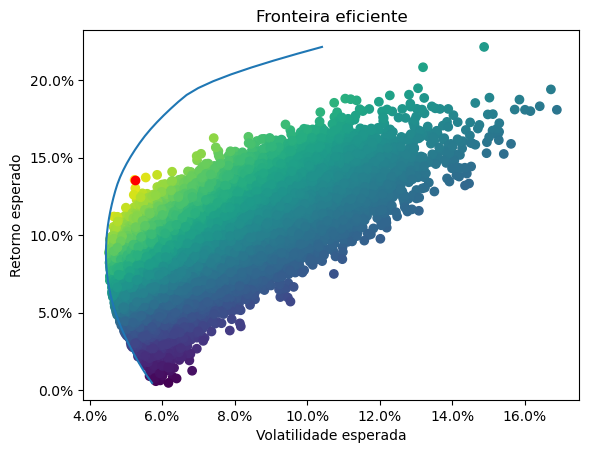

In [48]:
fig, ax = plt.subplots()

ax.scatter(tabela_volatilidades_esperadas, tabela_retornos_esperados_arit, c = tabela_sharpe)
plt.xlabel("Volatilidade esperada")
plt.ylabel("Retorno esperado")
plt.title("Fronteira eficiente", loc = 'center')
ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')
ax.scatter(tabela_volatilidades_esperadas[indice_do_sharpe_maximo], 
            tabela_retornos_esperados_arit[indice_do_sharpe_maximo], c = "red")
ax.plot(eixo_x_fronteira_eficiente, eixo_y_fronteira_eficiente)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')

plt.show()

In [49]:
data = bt.get(carteira, start='2010-01-01', end='2024-10-31')

In [50]:
# criando a estratégia
s = bt.Strategy('s', [bt.algos.RunMonthly(),
                       bt.algos.SelectAll(),
                       bt.algos.WeighEqually(),
                       bt.algos.Rebalance()])

In [51]:
test = bt.Backtest(s, data)
res = bt.run(test)

100%|██████████| 1/1 [00:00<00:00, 13.74it/s]


In [52]:
#comando para permitir que os gráficos sejam mostrados

plt.ioff()

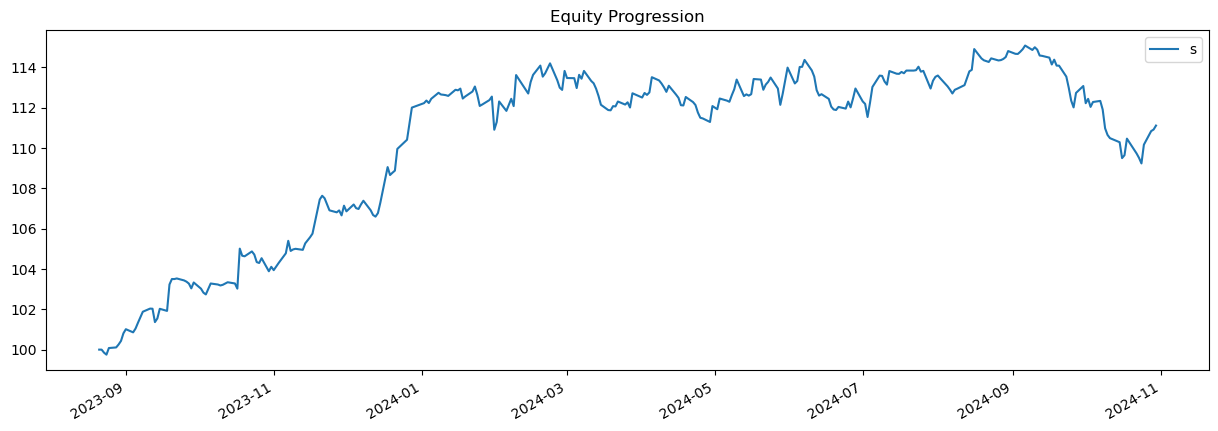

In [53]:
# plotando a curva de rentabilidade da carteira
res.plot();

plt.show()

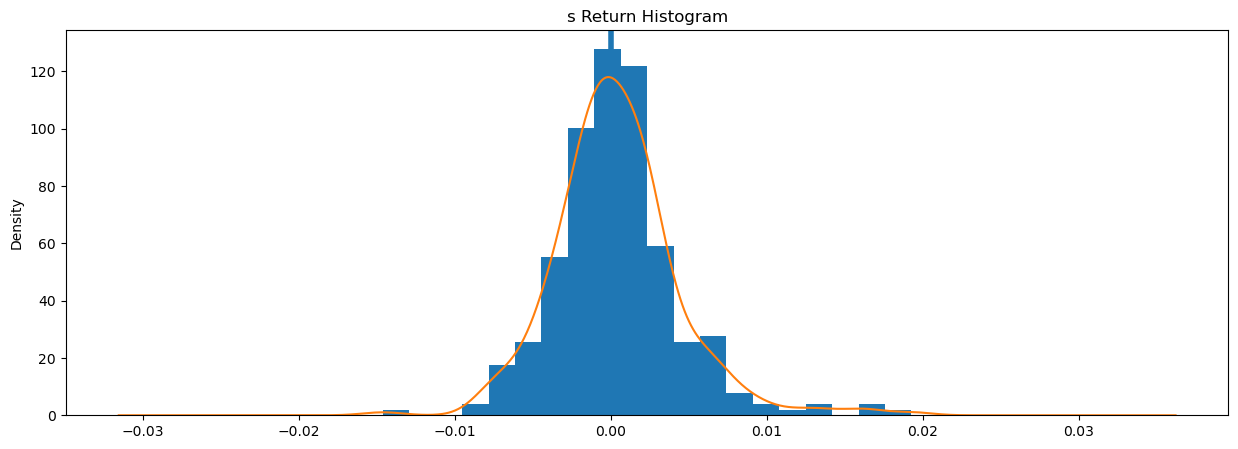

In [54]:
# ok and how does the return distribution look like?
res.plot_histogram()

plt.show()

In [55]:
# estatísticas consolidadas
res.display()

Stat                 s
-------------------  ----------
Start                2023-08-21
End                  2024-10-30
Risk-free rate       0.00%

Total Return         11.11%
Daily Sharpe         1.42
Daily Sortino        2.83
CAGR                 9.23%
Max Drawdown         -5.08%
Calmar Ratio         1.82

MTD                  -1.73%
3m                   -1.96%
6m                   -0.86%
YTD                  -0.80%
1Y                   6.95%
3Y (ann.)            -
5Y (ann.)            -
10Y (ann.)           -
Since Incep. (ann.)  9.23%

Daily Sharpe         1.42
Daily Sortino        2.83
Daily Mean (ann.)    9.05%
Daily Vol (ann.)     6.37%
Daily Skew           0.85
Daily Kurt           3.46
Best Day             1.93%
Worst Day            -1.46%

Monthly Sharpe       1.28
Monthly Sortino      3.93
Monthly Mean (ann.)  8.57%
Monthly Vol (ann.)   6.69%
Monthly Skew         0.48
Monthly Kurt         -0.77
Best Month           4.54%
Worst Month          -1.73%

Yearly Sharpe        -
Yea